In [1]:
!pip install scikit-surprise

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 3.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2610400 sha256=7ec512e36fcaaa76b5d5dddd05291effc423a910de9e4b464fbc358118b91fce
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise


In [1]:
!pip uninstall numpy

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Would remove:
    /usr/local/bin/f2py
    /usr/local/bin/numpy-config
    /usr/local/lib/python3.12/dist-packages/numpy-2.0.2.dist-info/*
    /usr/local/lib/python3.12/dist-packages/numpy.libs/libgfortran-040039e1-0352e75f.so.5.0.0
    /usr/local/lib/python3.12/dist-packages/numpy.libs/libquadmath-96973f99-934c22de.so.0.0.0
    /usr/local/lib/python3.12/dist-packages/numpy.libs/libscipy_openblas64_-99b71e71.so
    /usr/local/lib/python3.12/dist-packages/numpy/*
Proceed (Y/n)? ํY
Your response ('ํy') was not one of the expected responses: y, n, 
Proceed (Y/n)? y
  Successfully uninstalled numpy-2.0.2


In [2]:
!pip install numpy==1.26.4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 97.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


In [1]:
!pip install scikit-surprise

In [3]:
from surprise import Dataset, Reader, KNNBasic
from surprise.model_selection import train_test_split
from surprise import accuracy
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
reader = Reader(line_format='user item rating', sep=',', rating_scale=(1, 5), skip_lines=1)
data = Dataset.load_from_file('/content/drive/MyDrive/DataScience/Datasets/ratings.csv', reader=reader)

# แบ่งข้อมูลเป็น trainset และ testset
trainset, testset = train_test_split(data, test_size=0.25)

In [6]:
print('Number of Users:', trainset.n_users)
print('Number of Items:', trainset.n_items)
print('Max Rating:', trainset.rating_scale[1])
print('Min Rating:', trainset.rating_scale[0])
print('Number of Ratings:', trainset.n_ratings)

Number of Users: 943
Number of Items: 1644
Max Rating: 5
Min Rating: 1
Number of Ratings: 75000


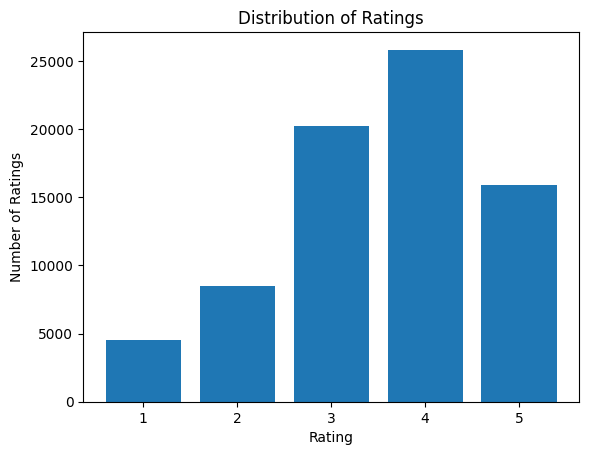

In [7]:
import matplotlib.pyplot as plt

ratings = [0, 0, 0, 0, 0]
for rating in trainset.all_ratings():
    ratings[int(rating[2])-1] += 1

plt.bar(['1', '2', '3', '4', '5'], ratings)
plt.xlabel('Rating')
plt.ylabel('Number of Ratings')
plt.title('Distribution of Ratings')
plt.show()

In [8]:
df_movies = pd.read_csv('/content/drive/MyDrive/DataScience/Datasets/movies.csv')
df_movies.drop(['release_date', 'video_release_date', 'imdb_url'], axis=1, inplace=True)
df_movies.head()

,movie_id,title,unknown,action,adventure,animation,childrens,comedy,crime,documentary,...,fantasy,film_noir,horror,musical,mystery,romance,sci_fi,thriller,war,western
0,1,Toy Story (1995),0,0,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),0,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0


In [10]:
# สร้าง mapping ระหว่าง inner_id ของ Surprise กับ movie_id จริง
item_raw_ids = {trainset.to_inner_iid(str(movie_id)): movie_id for movie_id in df_movies['movie_id'].unique() if str(movie_id) in trainset._raw2inner_id_items}

In [11]:
df = pd.DataFrame(trainset.all_ratings(), columns=['User', 'Item', 'Rating'])
df['User'] = df['User'].map(lambda x: trainset.to_raw_uid(x))
df['Item'] = df['Item'].map(lambda x: trainset.to_raw_iid(x))
pivot_table = df.pivot_table(index='User', columns='Item', values='Rating')
pivot_table.head()

Item,1,10,100,1000,1001,1002,1003,1004,1005,1006,...,990,991,992,993,994,995,996,997,998,999
User,,,,,,,,,,,,,,,,,,,,,
1,5.0,3.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,4.0,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
101,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
102,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
item_ratings = {}
for user, item, rating in trainset.all_ratings():
    if item not in item_ratings:
        item_ratings[item] = []
    item_ratings[item].append(rating)

item_ratings = {item: (sum(ratings) / len(ratings), len(ratings)) for item, ratings in item_ratings.items()}
sorted_items = sorted(item_ratings.items(), key=lambda x: x[1][0], reverse=True)

for item_inner_id, (rating, count) in sorted_items[:10]:
    movie_id = trainset.to_raw_iid(item_inner_id)
    movie_title = df_movies.loc[df_movies['movie_id'] == int(movie_id), 'title'].values[0]
    print('Movie:', movie_title, 'Rating:', rating, 'Number of Ratings:', count)

Movie: Santa with Muscles (1996) Rating: 5.0 Number of Ratings: 1
Movie: Saint of Fort Washington, The (1993) Rating: 5.0 Number of Ratings: 2
Movie: Star Kid (1997) Rating: 5.0 Number of Ratings: 2
Movie: Little City (1998) Rating: 5.0 Number of Ratings: 1
Movie: Marlene Dietrich: Shadow and Light (1996)  Rating: 5.0 Number of Ratings: 1
Movie: Prefontaine (1997) Rating: 5.0 Number of Ratings: 2
Movie: Great Day in Harlem, A (1994) Rating: 5.0 Number of Ratings: 1
Movie: Aiqing wansui (1994) Rating: 5.0 Number of Ratings: 1
Movie: Letter From Death Row, A (1998) Rating: 5.0 Number of Ratings: 1
Movie: They Made Me a Criminal (1939) Rating: 5.0 Number of Ratings: 1


In [13]:
min_user_rate=100
top_x=10

item_ratings = {}
for user, item, rating in trainset.all_ratings():
    if item not in item_ratings:
        item_ratings[item] = []
    item_ratings[item].append(rating)

item_ratings = {item: (sum(ratings) / len(ratings), len(ratings)) for item, ratings in item_ratings.items()}
sorted_items = sorted(item_ratings.items(), key=lambda x: x[1][0], reverse=True)

filtered_items = [item for item in sorted_items if item[1][1] > min_user_rate][:top_x]
for item_inner_id, (rating, count) in filtered_items:
    movie_id = trainset.to_raw_iid(item_inner_id)
    movie_title = df_movies.loc[df_movies['movie_id'] == int(movie_id), 'title'].values[0]
    print('Movie:', movie_title, 'Rating:', rating, 'Number of Ratings:', count)

Movie: Schindler's List (1993) Rating: 4.46829268292683 Number of Ratings: 205
Movie: Casablanca (1942) Rating: 4.463917525773196 Number of Ratings: 194
Movie: Shawshank Redemption, The (1994) Rating: 4.436619718309859 Number of Ratings: 213
Movie: Usual Suspects, The (1995) Rating: 4.407766990291262 Number of Ratings: 206
Movie: Rear Window (1954) Rating: 4.383116883116883 Number of Ratings: 154
Movie: Citizen Kane (1941) Rating: 4.328859060402684 Number of Ratings: 149
Movie: Star Wars (1977) Rating: 4.321507760532151 Number of Ratings: 451
Movie: To Kill a Mockingbird (1962) Rating: 4.291666666666667 Number of Ratings: 168
Movie: Titanic (1997) Rating: 4.288389513108614 Number of Ratings: 267
Movie: Vertigo (1958) Rating: 4.282608695652174 Number of Ratings: 138


In [14]:
min_user_rate=100
top_x=10

lowest_filtered_items = [item for item in sorted_items if item[1][1] > min_user_rate][-top_x:]
for item_inner_id, (rating, count) in lowest_filtered_items:
    movie_id = trainset.to_raw_iid(item_inner_id)
    movie_title = df_movies.loc[df_movies['movie_id'] == int(movie_id), 'title'].values[0]
    print('Movie:', movie_title, 'Rating:', rating, 'Number of Ratings:', count)

Movie: Dante's Peak (1997) Rating: 2.9447513812154695 Number of Ratings: 181
Movie: Lost World: Jurassic Park, The (1997) Rating: 2.93859649122807 Number of Ratings: 114
Movie: Nutty Professor, The (1996) Rating: 2.876923076923077 Number of Ratings: 130
Movie: Mars Attacks! (1996) Rating: 2.8433734939759034 Number of Ratings: 166
Movie: Beavis and Butt-head Do America (1996) Rating: 2.8181818181818183 Number of Ratings: 121
Movie: Multiplicity (1996) Rating: 2.8095238095238093 Number of Ratings: 105
Movie: Volcano (1997) Rating: 2.804733727810651 Number of Ratings: 169
Movie: Batman Returns (1992) Rating: 2.7211538461538463 Number of Ratings: 104
Movie: George of the Jungle (1997) Rating: 2.5775862068965516 Number of Ratings: 116
Movie: Crash (1996) Rating: 2.548076923076923 Number of Ratings: 104


In [22]:
model = KNNBasic(k=5, sim_options={'name': 'pearson', 'user_based': True})
model.fit(trainset)

Computing the pearson similarity matrix...
Done computing similarity matrix.


In [23]:
predictions = model.test(testset)
accuracy.rmse(predictions)

RMSE: 1.0835


1.0835084041714178

In [24]:
inner_id = trainset.to_inner_iid(str(314))  # แปลง movie_id เป็น inner_id
prediction = model.predict(196, trainset.to_raw_iid(inner_id))  # ทำนาย rating
print(f'Predicted rating for user 196 and movie 314: {prediction.est}')

Predicted rating for user 196 and movie 314: 3.53564


In [26]:
def get_Iu(uid):
    """ return the number of items rated by given user
    args:
      uid: the id of the user
    returns:
      the number of items rated by the user
    """
    try:
        return len(trainset.ur[trainset.to_inner_uid(uid)])
    except ValueError: # user was not part of the trainset
        return 0

def get_Ui(iid):
    """ return number of users that have rated given item
    args:
      iid: the raw id of the item
    returns:
      the number of users that have rated the item.
    """
    try:
        return len(trainset.ir[trainset.to_inner_iid(iid)])
    except ValueError:
        return 0


predictions = model.test(testset)
df = pd.DataFrame(predictions, columns=['uid', 'iid', 'rui', 'est', 'details'])
#['user', 'movie', 'rating_actual', 'rating_predict', 'details']
df['Iu'] = df.uid.apply(get_Iu)
df['Ui'] = df.iid.apply(get_Ui)
df['err'] = abs(df.est - df.rui)

best_predictions = df.sort_values(by='err')[:10]
worst_predictions = df.sort_values(by='err')[-10:]

In [27]:
best_predictions

,uid,iid,rui,est,details,Iu,Ui,err
15090,36,310,4.0,4.0,"{'actual_k': 5, 'was_impossible': False}",12,116,0.0
380,790,358,2.0,2.0,"{'actual_k': 5, 'was_impossible': False}",176,100,0.0
8296,328,1439,3.0,3.0,"{'actual_k': 1, 'was_impossible': False}",211,2,0.0
377,182,1,4.0,4.0,"{'actual_k': 5, 'was_impossible': False}",21,342,0.0
5730,941,147,4.0,4.0,"{'actual_k': 5, 'was_impossible': False}",12,141,0.0
19086,405,437,1.0,1.0,"{'actual_k': 3, 'was_impossible': False}",532,3,0.0
24135,585,1558,5.0,5.0,"{'actual_k': 1, 'was_impossible': False}",61,3,0.0
5723,188,259,3.0,3.0,"{'actual_k': 5, 'was_impossible': False}",78,116,0.0
8305,587,286,4.0,4.0,"{'actual_k': 5, 'was_impossible': False}",64,343,0.0
16798,639,242,4.0,4.0,"{'actual_k': 5, 'was_impossible': False}",117,89,0.0


In [28]:
worst_predictions

,uid,iid,rui,est,details,Iu,Ui,err
20155,405,853,1.0,4.690207,"{'actual_k': 5, 'was_impossible': False}",532,12,3.690207
3462,731,205,1.0,4.747831,"{'actual_k': 5, 'was_impossible': False}",67,103,3.747831
20300,910,181,1.0,4.797946,"{'actual_k': 5, 'was_impossible': False}",42,395,3.797946
21336,64,32,1.0,4.809522,"{'actual_k': 5, 'was_impossible': False}",152,60,3.809522
8912,405,183,1.0,4.810077,"{'actual_k': 5, 'was_impossible': False}",532,217,3.810077
20936,648,9,1.0,4.811655,"{'actual_k': 5, 'was_impossible': False}",238,215,3.811655
22412,617,170,1.0,4.847417,"{'actual_k': 5, 'was_impossible': False}",86,97,3.847417
10387,534,1054,5.0,1.123893,"{'actual_k': 5, 'was_impossible': False}",55,15,3.876107
14003,405,1405,1.0,4.930077,"{'actual_k': 3, 'was_impossible': False}",532,4,3.930077
3770,286,1316,5.0,1.000000,"{'actual_k': 1, 'was_impossible': False}",209,2,4.000000


In [29]:
from surprise import SVD

model = SVD()
model.fit(trainset)

In [30]:
predictions = model.test(testset)
accuracy.rmse(predictions)

RMSE: 0.9411


0.9410895203503237

In [31]:
user_x='196'
# Get all unique movie IDs from the raw dataset
all_movie_ids = set(data.raw_ratings[i][1] for i in range(len(data.raw_ratings)))

# Convert user ID to the internal representation
inner_user_id = trainset.to_inner_uid(user_x)

# Get all movie IDs rated by user x (in the internal format)
movies_rated_by_user_x = set(trainset.ur[inner_user_id])

# Filter movies to include only those present in the trainset
movies_to_predict = [
    movie_id for movie_id in all_movie_ids
    if movie_id in trainset._raw2inner_id_items and trainset.to_inner_iid(movie_id) not in movies_rated_by_user_x
]

# Make predictions for user x
predictions = [model.predict(user_x, movie_id) for movie_id in movies_to_predict]

# Get top N recommendations
top_n = sorted(predictions, key=lambda x: x.est, reverse=True)[:10]

# Display recommendations
print("Top 10 Recommendations for User", user_x ,":")
for pred in top_n:
    print(f"Movie ID: {pred.iid}, Estimated Rating: {pred.est}")


Top 10 Recommendations for User 196 :
Movie ID: 408, Estimated Rating: 4.638708668519448
Movie ID: 483, Estimated Rating: 4.594603447861825
Movie ID: 136, Estimated Rating: 4.593431515148513
Movie ID: 513, Estimated Rating: 4.560518993977853
Movie ID: 427, Estimated Rating: 4.517795495577125
Movie ID: 488, Estimated Rating: 4.503553787802822
Movie ID: 480, Estimated Rating: 4.501960150096094
Movie ID: 98, Estimated Rating: 4.500090146108944
Movie ID: 318, Estimated Rating: 4.488383915958098
Movie ID: 515, Estimated Rating: 4.481266375790228


In [32]:
import pandas as pd
from surprise import SVD, SVDpp, SlopeOne, NMF, NormalPredictor, KNNBaseline, KNNBasic, KNNWithMeans, KNNWithZScore, BaselineOnly, CoClustering
from surprise.model_selection import cross_validate

# Initialize an empty list to store benchmark results
benchmark = []

# Iterate over all algorithms
for algorithm in [SVD(), SVDpp(), SlopeOne(), NMF(), NormalPredictor(), KNNBaseline(), KNNBasic(), KNNWithMeans(), KNNWithZScore(), BaselineOnly(), CoClustering()]:
    # Perform cross validation
    results = cross_validate(algorithm, data, measures=['RMSE'], cv=3, verbose=False)

    # Get results & append algorithm name using pd.concat()
    tmp = pd.DataFrame.from_dict(results).mean(axis=0)
    tmp = pd.concat([tmp, pd.Series([str(algorithm).split(' ')[0].split('.')[-1]], index=['Algorithm'])])
    benchmark.append(tmp)

# Convert results to DataFrame and sort by RMSE
df_results = pd.DataFrame(benchmark)
df_results.set_index('Algorithm', inplace=True)
df_results.sort_values('test_rmse')

Estimating biases using als...
Computing the msd similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the msd similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Estimating biases using als...


,test_rmse,fit_time,test_time
Algorithm,,,
SVDpp,0.928625,16.888354,5.710515
KNNBaseline,0.935585,0.418948,5.078311
SVD,0.944401,1.232852,0.270985
BaselineOnly,0.946885,0.190455,0.201649
SlopeOne,0.950268,0.531373,3.784926
KNNWithMeans,0.956196,0.287491,4.719524
KNNWithZScore,0.957673,0.311581,4.818521
NMF,0.974069,1.419583,0.220056
CoClustering,0.974159,1.291719,0.252782
